# Model-Based Feature Analysis
Statistical comparison of saliency and probability-based features between good and poor segmentations.
Follows the same methodology as Shape_Generate_Charts.ipynb, GLCM_Generate_Charts.ipynb, etc.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from scipy.stats import mannwhitneyu
import json
import pickle as pkl
import warnings

warnings.filterwarnings('ignore')

/Users/suvodeepmajumder/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/suvodeepmajumder/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Helper Functions

In [2]:
def load_unet_result(path, _print=False):
    unet_df = pd.read_csv(path, index_col='Unnamed: 0')
    index_values = [idx.split('-seg')[0] for idx in unet_df.index]
    unet_df.index = index_values
    unet_df.drop(['WT jaccard', 'TC jaccard', 'ET jaccard'], axis=1, inplace=True)
    if _print:
        print('****UNet******')
        print(unet_df.describe())
    return unet_df


def load_nnunet_result(path, _print=False):
    with open(path, 'r') as f:
        data = json.load(f)
    WT, TC, ET, file_name = [], [], [], []
    for case in data['metric_per_case']:
        WT.append(case['metrics']['(2, 1, 3)']['Dice'])
        TC.append(case['metrics']['(2, 3)']['Dice'])
        ET.append(case['metrics']['(3,)']['Dice'])
        file_name.append(case['reference_file'].split('/')[-1].split('.')[0])
    df = pd.DataFrame(zip(WT, TC, ET), columns=['WT dice', 'TC dice', 'ET dice'], index=file_name)
    if _print:
        print('****nnUNet******')
        print(df.describe())
    return df


def load_TransBTS_result(path, _print=False):
    with open(path, 'r') as f:
        data = json.load(f)
    WT, TC, ET, file_name = [], [], [], []
    for case_id, case in data.items():
        WT.append(case['WT'][0])
        TC.append(case['TC'][0])
        ET.append(case['ET'][0])
        file_name.append(case_id)
    df = pd.DataFrame(zip(WT, TC, ET), columns=['WT dice', 'TC dice', 'ET dice'], index=file_name)
    if _print:
        print('****TransBTS******')
        print(df.describe())
    return df


def get_overlaps(unet_df, TransBTS_df, nnunet_df,
                 WT_thresh=0.91, TC_thresh=0.86, ET_thresh=0.85):
    def bad_idx(df):
        return df[(df['WT dice'] < WT_thresh) &
                  (df['TC dice'] < TC_thresh) &
                  (df['ET dice'] < ET_thresh)].index.tolist()

    unet_bad  = set(bad_idx(unet_df))
    tbts_bad  = set(bad_idx(TransBTS_df))
    nnun_bad  = set(bad_idx(nnunet_df))

    all_overlaps       = list(unet_bad & tbts_bad & nnun_bad)
    unet_nnunet_overlaps = list(unet_bad & nnun_bad)
    return all_overlaps, unet_nnunet_overlaps


def filter_numeric_columns(df):
    numeric_df = df.apply(pd.to_numeric, errors='coerce')
    return numeric_df.dropna(axis=1, how='all')


def cliffs_delta(x, y):
    n_x, n_y = len(x), len(y)
    N_gr = sum(xi > yi for xi in x for yi in y)
    N_ls = sum(xi < yi for xi in x for yi in y)
    return (N_gr - N_ls) / (n_x * n_y)


def categorize_effect_size(delta):
    abs_delta = abs(delta)
    if abs_delta < 0.147:
        return 'No'
    elif abs_delta < 0.33:
        return 'Small'
    elif abs_delta < 0.474:
        return 'Medium'
    else:
        return 'Large'


def add_significance_indicator(ax, data_good, data_bad, x_pos, alpha=0.05):
    """Run Mann-Whitney U, add label on top axis, return (p_value, delta, effect_size)."""
    stat, p_value = mannwhitneyu(data_good, data_bad)
    if p_value < alpha:
        delta_value = cliffs_delta(data_good, data_bad)
        effect_size = categorize_effect_size(delta_value)
        label = f'* {effect_size}'
        ax_top = ax.secondary_xaxis('top')
        ax_top.set_xticks([x_pos + 0.5])
        ax_top.set_xticklabels([label], rotation=0, ha='center')
        for lbl in ax_top.get_xticklabels():
            lbl.set_color('blue')
            lbl.set_fontsize(9)
        return p_value, delta_value, effect_size
    return p_value, None, 'No'


def make_boxplot(ax, good_data, bad_data, group_labels):
    """Draw a 2-box (good/bad) group per label on ax."""
    flat = []
    for g, b in zip(good_data, bad_data):
        flat += [g, b]
    box = ax.boxplot(flat, patch_artist=True, widths=0.5, showfliers=False)
    colors = ['lightblue', 'lightcoral'] * len(group_labels)
    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)
    for median in box['medians']:
        median.set_color('black')
    tick_pos = [1.5 + 2 * i for i in range(len(group_labels))]
    ax.set_xticks(tick_pos)
    ax.set_xticklabels(group_labels)
    for pos in [2.5 + 2 * i for i in range(len(group_labels) - 1)]:
        ax.axvline(x=pos, color='gray', linestyle='--', linewidth=1)
    sub_labels = ['Good', 'Poor']
    for j, x in enumerate(range(1, 2 * len(group_labels) + 1)):
        ax.text(
            x,
            ax.get_ylim()[0] - (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.1,
            sub_labels[j % 2], ha='center', va='center', fontsize=9
        )
    return box


print('Helper functions loaded.')

Helper functions loaded.


## Load Performance Data & Compute Good / Bad Splits

In [3]:
WT_THRESH = 0.91
TC_THRESH = 0.86
ET_THRESH = 0.85

unet_df     = load_unet_result('../../Results/Result/Vanilla_Unet/Unet_test_dice.csv')
nnunet_df   = load_nnunet_result('../../Results/Result/nnUnet/nnUNetTrainerNoDA/summary.json')
transbts_df = load_TransBTS_result('../../Results/Result/TransBTS/submission/TransBTS2023-11-03/TransBTS_summary.json')

all_overlaps, unet_nnunet_overlaps = get_overlaps(
    unet_df, transbts_df, nnunet_df, WT_THRESH, TC_THRESH, ET_THRESH
)

performance_df = unet_df.copy()

print(f'Total cases: {len(unet_df)}')
print(f'unet+nnunet bad overlap (concordant poor): {len(unet_nnunet_overlaps)}')
good_mask = ((performance_df['WT dice'] >= WT_THRESH) &
             (performance_df['TC dice'] >= TC_THRESH) &
             (performance_df['ET dice'] >= ET_THRESH))
print(f'Concordant good: {good_mask.sum()}')

Total cases: 939
unet+nnunet bad overlap (concordant poor): 47
Concordant good: 404


## Load Model-Based Features

In [4]:
# --- Saliency features ---
saliency_df = pd.read_csv('../../Results/Analysis_Results/Saliency/Saliency.csv', index_col=0)
print('Saliency shape:', saliency_df.shape)
print('Saliency columns:', saliency_df.columns.tolist())

# --- Probability features ---
prob_df = pd.read_csv('../../Results/Analysis_Results/probability/Probability_Tumor_boundary.csv', index_col=0)
print('\nProbability shape:', prob_df.shape)
print('Probability columns:', prob_df.columns.tolist())

Saliency shape: (939, 12)
Saliency columns: ['Flair_WT_mean', 'Flair_TC_mean', 'Flair_ET_mean', 'T2_WT_mean', 'T2_TC_mean', 'T2_ET_mean', 'T1_WT_mean', 'T1_TC_mean', 'T1_ET_mean', 'T1ce_WT_mean', 'T1ce_TC_mean', 'T1ce_ET_mean']

Probability shape: (939, 9)
Probability columns: ['WT_dilated', 'WT_eroded', 'WT_boundary', 'WT_dilated_grad_magnitude_mean', 'WT_eroded_grad_magnitude_mean', 'WT_boundary_grad_magnitude_mean', '< 0.33', '> 0.33 & < 0.67', '> 0.67']


In [5]:
# Merge with performance scores
saliency_perf_df = saliency_df.merge(performance_df, left_index=True, right_index=True).dropna()
prob_perf_df     = prob_df.merge(performance_df, left_index=True, right_index=True).dropna()

print('Saliency + performance:', saliency_perf_df.shape)
print('Probability + performance:', prob_perf_df.shape)

# Good / bad splits — same concordance logic as all other feature notebooks
def split_good_bad(df, overlaps):
    bad = df[
        (df['WT dice'] < WT_THRESH) &
        (df['TC dice'] < TC_THRESH) &
        (df['ET dice'] < ET_THRESH)
    ]
    bad = bad[bad.index.isin(overlaps)]
    good = df[
        (df['WT dice'] >= WT_THRESH) &
        (df['TC dice'] >= TC_THRESH) &
        (df['ET dice'] >= ET_THRESH)
    ]
    return good, bad

sal_good, sal_bad   = split_good_bad(saliency_perf_df, unet_nnunet_overlaps)
prob_good, prob_bad = split_good_bad(prob_perf_df,     unet_nnunet_overlaps)

print(f'\nSaliency  — good: {len(sal_good)}, bad: {len(sal_bad)}')
print(f'Probability — good: {len(prob_good)}, bad: {len(prob_bad)}')

Saliency + performance: (939, 15)
Probability + performance: (939, 12)

Saliency  — good: 404, bad: 47
Probability — good: 404, bad: 47


## Combined Model-Based Features Figure
**(a) Saliency** — 12 features: mean gradient saliency per MRI modality (Flair, T2, T1, T1ce) × tumor subregion (WT, TC, ET).

**(b) Probability** — 36 features derived from voxel-wise softmax probabilities. Rows: Mean probability, P<0.33, P 0.33–0.67, P>0.67. Columns: Dilated, Eroded, Boundary zone.

Output saved to `ModelBased_Combined.pdf`.

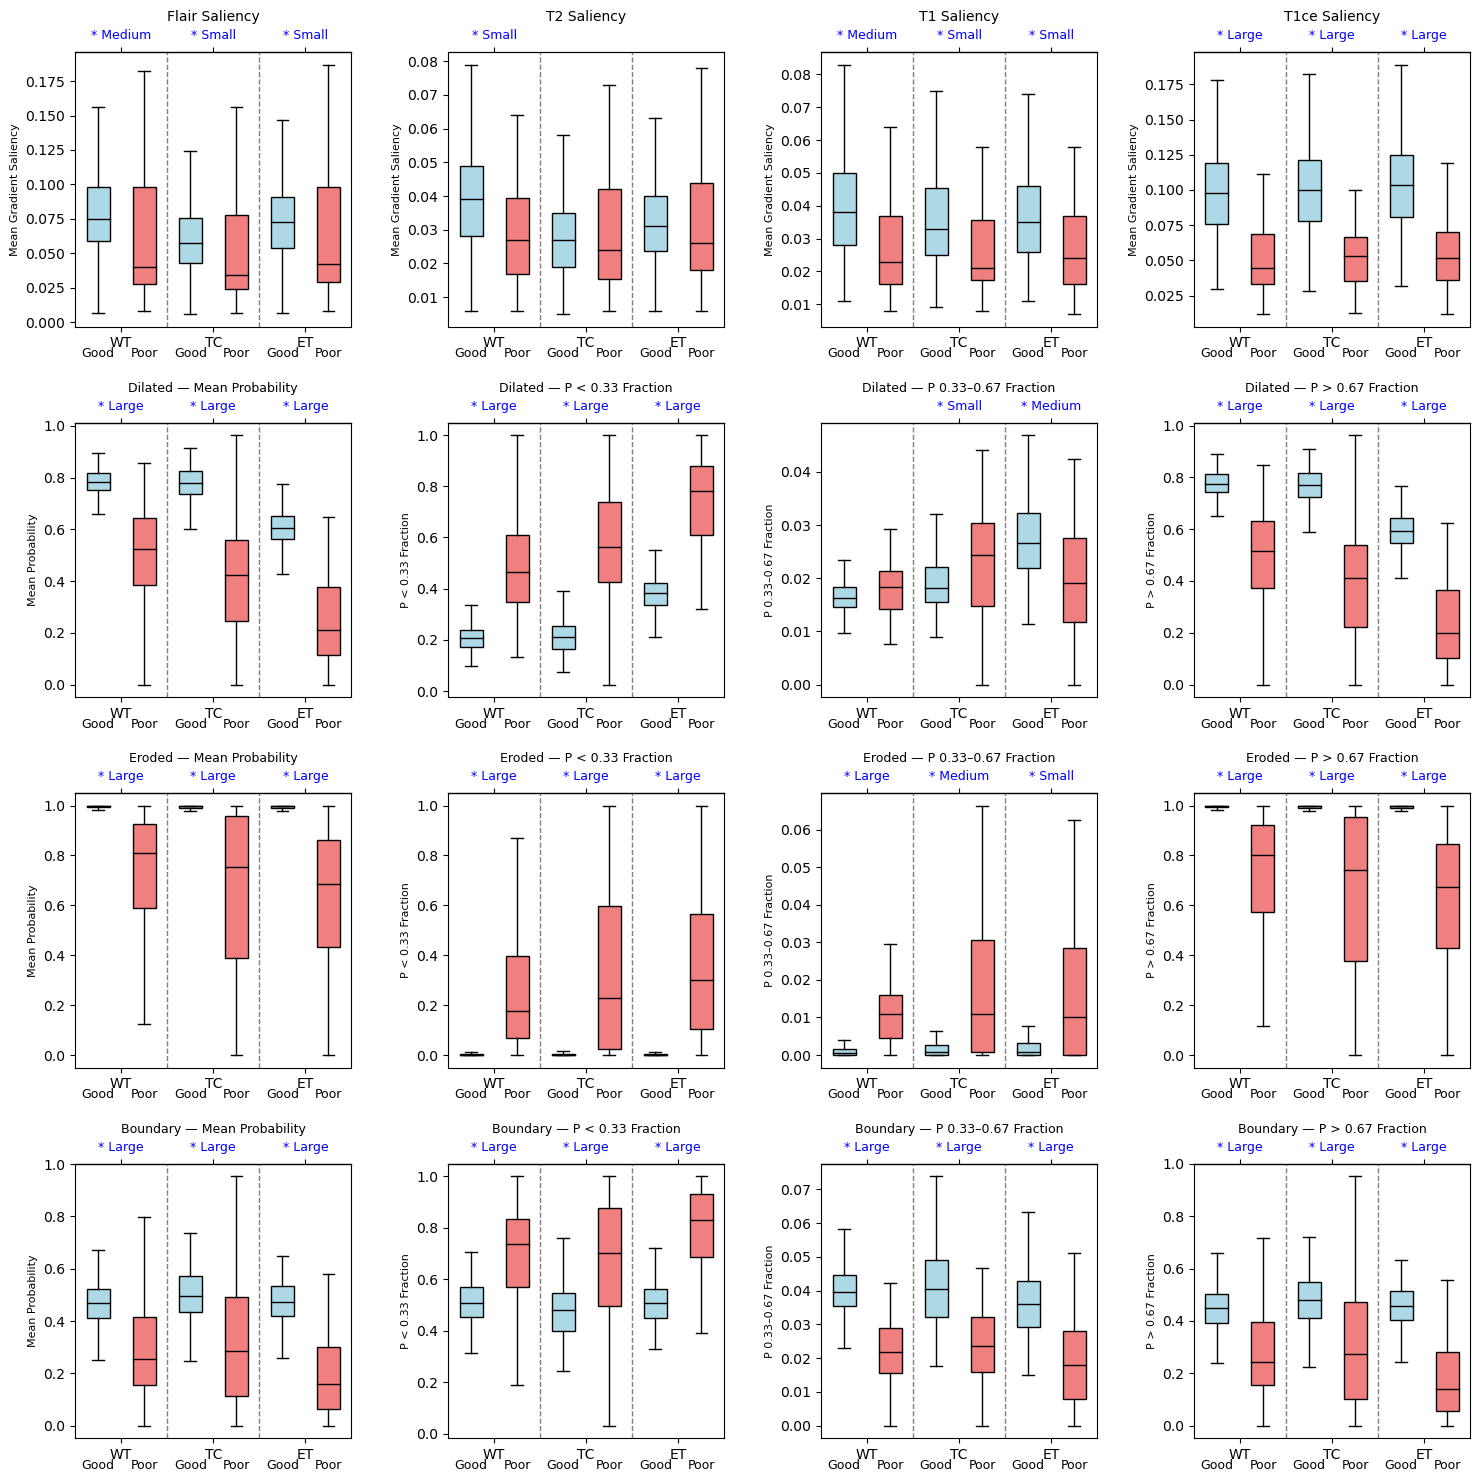

Combined figure saved → ModelBased_Combined.pdf


In [6]:
from matplotlib.gridspec import GridSpec

MODALITIES  = ['Flair', 'T2', 'T1', 'T1ce']
SUBREGIONS  = ['WT', 'TC', 'ET']
ZONES       = ['dilated', 'eroded', 'boundary']
ZONE_LABELS = {'dilated': 'Dilated', 'eroded': 'Eroded', 'boundary': 'Boundary'}
STATS       = ['mean', 'lt033', '033to067', 'gt067']
STAT_LABELS = {
    'mean':     'Mean Probability',
    'lt033':    'P < 0.33 Fraction',
    '033to067': 'P 0.33\u20130.67 Fraction',
    'gt067':    'P > 0.67 Fraction',
}

def get_col(region, zone, stat):
    return f'{region}_{zone}' if stat == 'mean' else f'{region}_{zone}_{stat}'

# ── Load probability data ──────────────────────────────────────────────────────
prob_all_df = pd.read_csv('../../Results/Analysis_Results/probability/Probability_AllSubregions.csv', index_col=0)
prob_all_perf_df = prob_all_df.merge(performance_df, left_index=True, right_index=True).dropna()
prob_all_good, prob_all_bad = split_good_bad(prob_all_perf_df, unet_nnunet_overlaps)
prob_all_good_num = filter_numeric_columns(prob_all_good)
prob_all_bad_num  = filter_numeric_columns(prob_all_bad)

sal_good_num = filter_numeric_columns(sal_good)
sal_bad_num  = filter_numeric_columns(sal_bad)

# ── Build combined figure ──────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 18))
gs  = GridSpec(4, 4, figure=fig, hspace=0.35, wspace=0.35)

sal_axes  = [fig.add_subplot(gs[0, i]) for i in range(4)]
prob_axes = [[fig.add_subplot(gs[z+1, s]) for s in range(4)] for z in range(3)]


# ── Saliency panels ────────────────────────────────────────────────────────────
summary_saliency = {}
for idx, modality in enumerate(MODALITIES):
    ax = sal_axes[idx]
    feat_key = f'{modality}_mean'
    summary_saliency[feat_key] = {}

    good_data = [sal_good_num[f'{modality}_{sr}_mean'] for sr in SUBREGIONS]
    bad_data  = [sal_bad_num[f'{modality}_{sr}_mean']  for sr in SUBREGIONS]

    make_boxplot(ax, good_data, bad_data, SUBREGIONS)
    ax.set_title(f'{modality} Saliency', fontsize=10)
    ax.set_ylabel('Mean Gradient Saliency', fontsize=8)

    for j, sr in enumerate(SUBREGIONS):
        p_val, delta, effect = add_significance_indicator(
            ax, good_data[j], bad_data[j], x_pos=1 + 2*j
        )
        summary_saliency[feat_key][sr] = {
            'median_good':  float(np.median(good_data[j])),
            'iqr_good':     float(np.percentile(good_data[j], 75) - np.percentile(good_data[j], 25)),
            'median_bad':   float(np.median(bad_data[j])),
            'iqr_bad':      float(np.percentile(bad_data[j], 75) - np.percentile(bad_data[j], 25)),
            'p_value':      float(p_val),
            'cliffs_delta': float(delta) if delta is not None else None,
            'effect_size':  effect,
        }

# ── Probability panels: rows = zones, cols = stats ────────────────────────────
summary_probability = {}
for z_idx, zone in enumerate(ZONES):
    for s_idx, stat in enumerate(STATS):
        ax = prob_axes[z_idx][s_idx]
        panel_key = f'{zone}_{stat}'
        summary_probability[panel_key] = {}

        good_data = [prob_all_good_num[get_col(sr, zone, stat)].dropna() for sr in SUBREGIONS]
        bad_data  = [prob_all_bad_num[get_col(sr, zone, stat)].dropna()  for sr in SUBREGIONS]

        make_boxplot(ax, good_data, bad_data, SUBREGIONS)
        ax.set_title(f'{ZONE_LABELS[zone]} \u2014 {STAT_LABELS[stat]}', fontsize=9)
        ax.set_ylabel(STAT_LABELS[stat], fontsize=8)

        for j, sr in enumerate(SUBREGIONS):
            p_val, delta, effect = add_significance_indicator(
                ax, good_data[j], bad_data[j], x_pos=1 + 2*j
            )
            summary_probability[panel_key][sr] = {
                'median_good':  float(np.median(good_data[j])),
                'iqr_good':     float(np.percentile(good_data[j], 75) - np.percentile(good_data[j], 25)),
                'median_bad':   float(np.median(bad_data[j])),
                'iqr_bad':      float(np.percentile(bad_data[j], 75) - np.percentile(bad_data[j], 25)),
                'p_value':      float(p_val),
                'cliffs_delta': float(delta) if delta is not None else None,
                'effect_size':  effect,
            }

# fig.suptitle('Model-Based Features: Good vs Poor Segmentations', fontsize=14, y=1.005)
plt.savefig('../../Results/final_figures/ModelBased_Combined.pdf', bbox_inches='tight')
plt.show()
print('Combined figure saved \u2192 ModelBased_Combined.pdf')

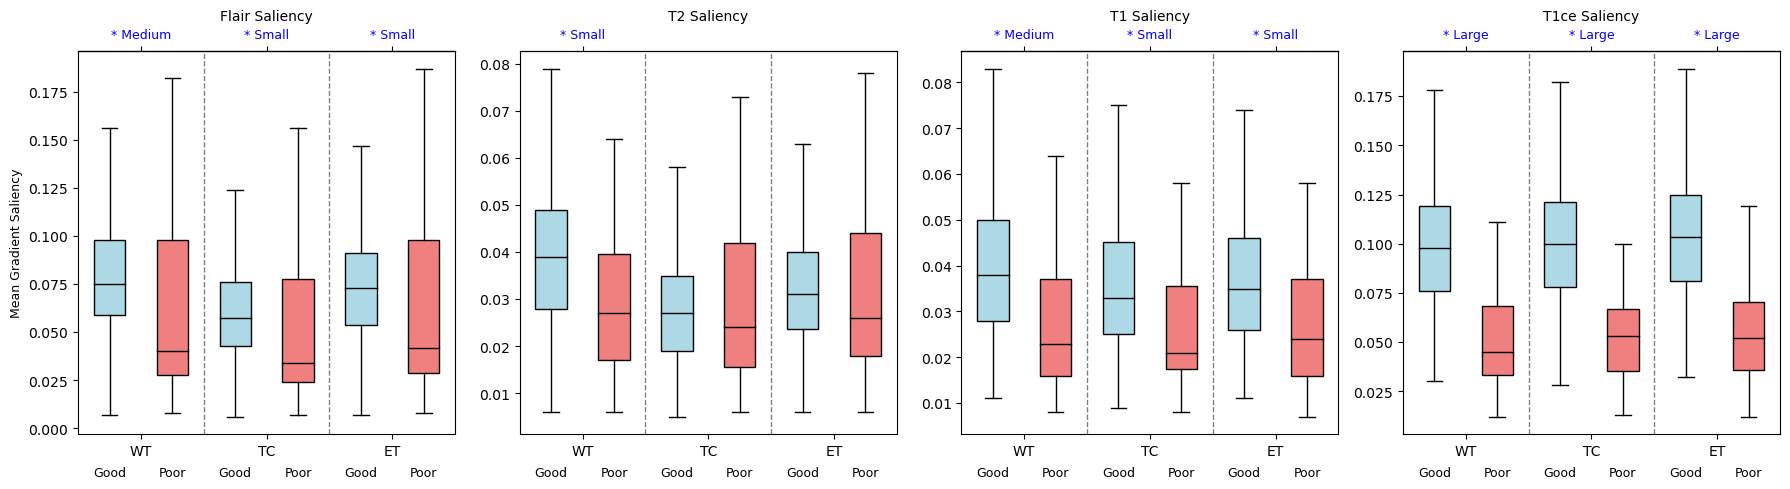

Saved → ModelBased_Saliency.pdf


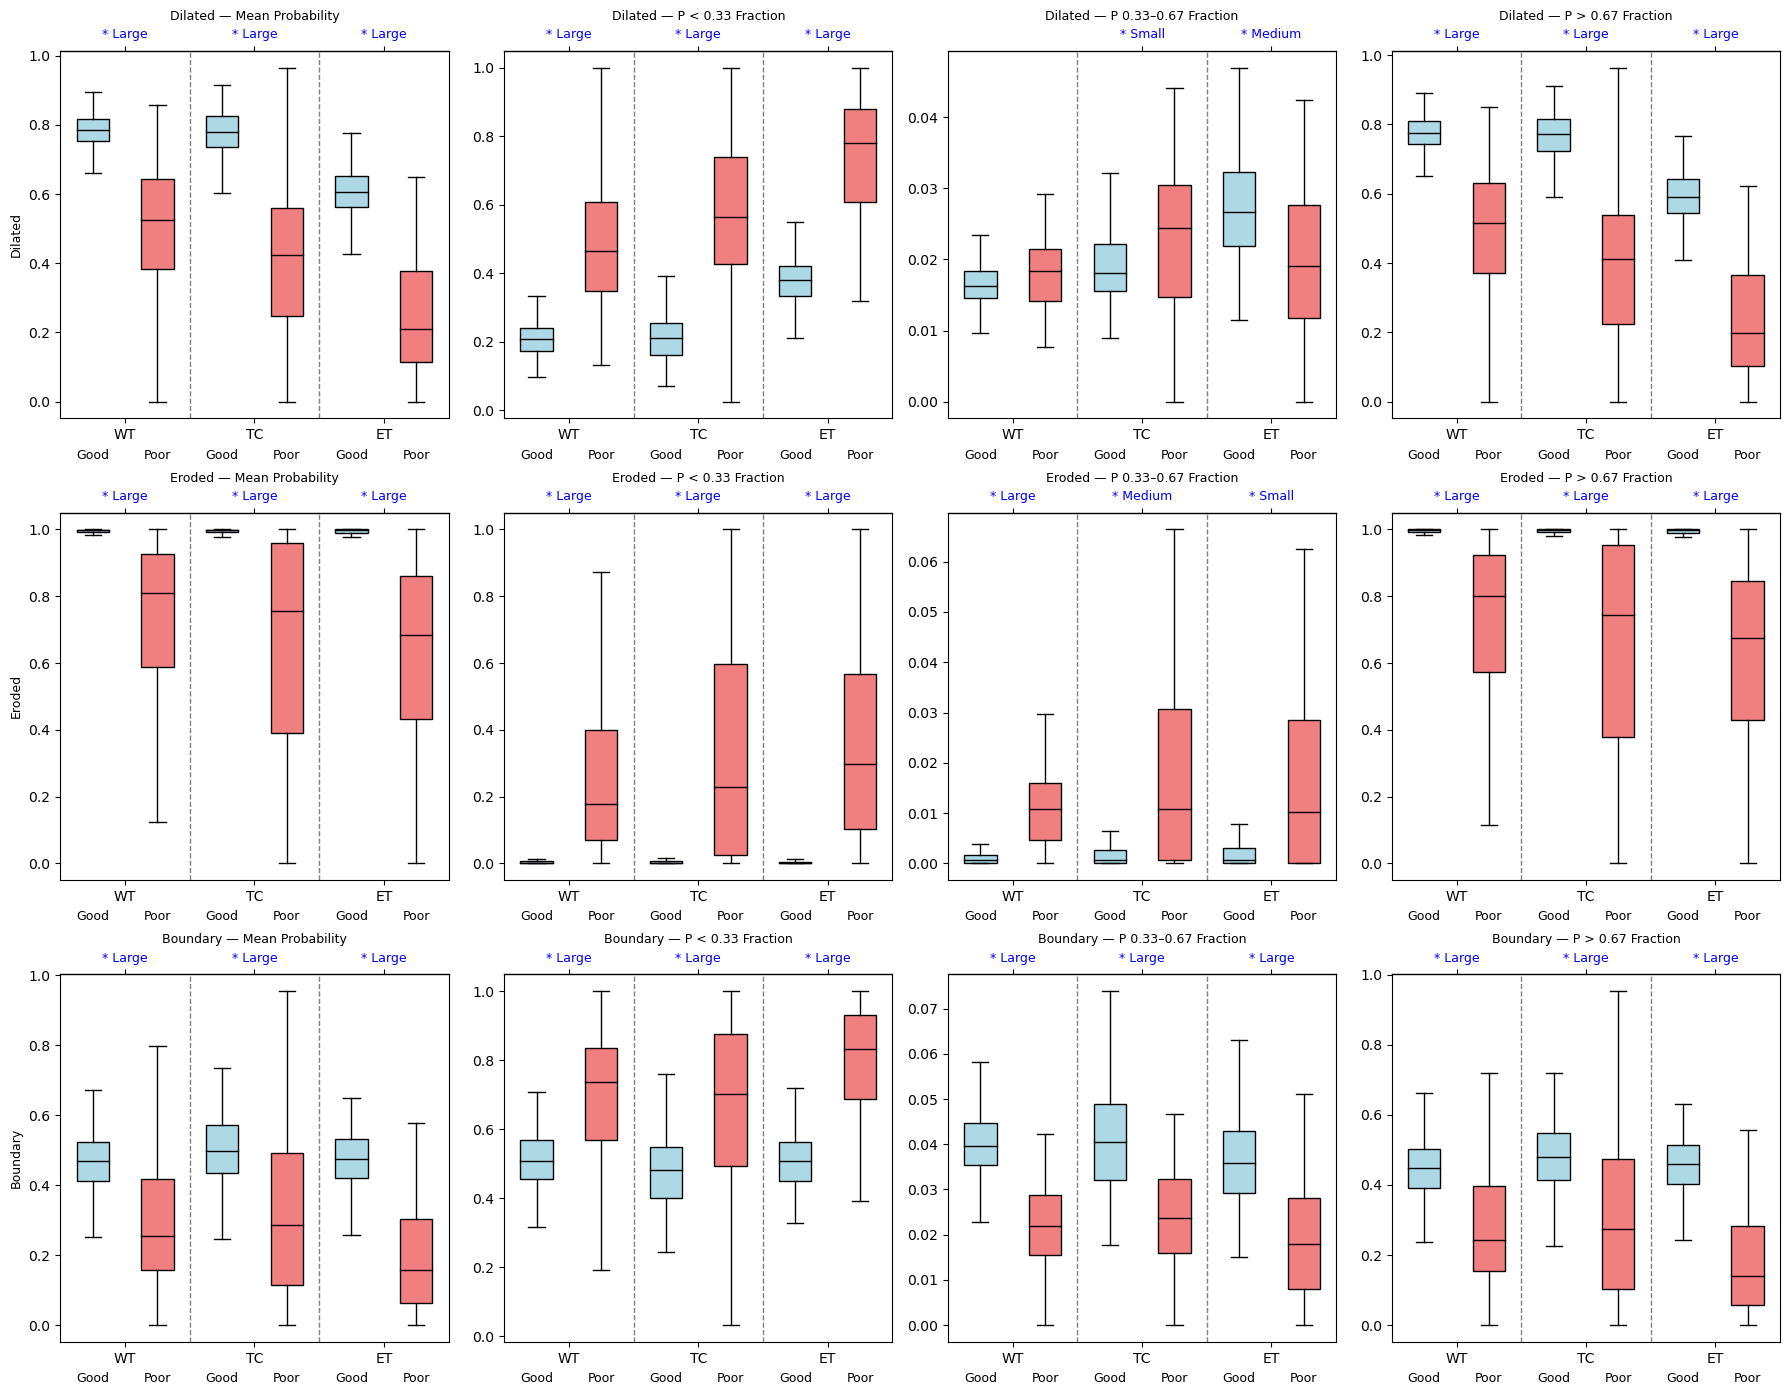

Saved → ModelBased_Probability.pdf


In [7]:

# ── Separate Saliency figure (for appendix Fig 1) ────────────────────────────
fig_sal, sal_axes_sep = plt.subplots(1, 4, figsize=(18, 5))

for idx, modality in enumerate(MODALITIES):
    ax = sal_axes_sep[idx]
    good_data = [sal_good_num[f'{modality}_{sr}_mean'] for sr in SUBREGIONS]
    bad_data  = [sal_bad_num[f'{modality}_{sr}_mean']  for sr in SUBREGIONS]
    make_boxplot(ax, good_data, bad_data, SUBREGIONS)
    ax.set_title(f'{modality} Saliency', fontsize=10)
    if idx == 0:
        ax.set_ylabel('Mean Gradient Saliency', fontsize=9)
    for j, sr in enumerate(SUBREGIONS):
        add_significance_indicator(ax, good_data[j], bad_data[j], x_pos=1 + 2*j)

plt.tight_layout()
plt.savefig('../../Results/final_figures/ModelBased_Saliency.pdf', bbox_inches='tight')
plt.show()
print('Saved → ModelBased_Saliency.pdf')

# ── Separate Probability figure (for appendix Fig 2) ─────────────────────────
fig_prob, prob_axes_sep = plt.subplots(3, 4, figsize=(18, 14))

for z_idx, zone in enumerate(ZONES):
    for s_idx, stat in enumerate(STATS):
        ax = prob_axes_sep[z_idx][s_idx]
        good_data = [prob_all_good_num[get_col(sr, zone, stat)].dropna() for sr in SUBREGIONS]
        bad_data  = [prob_all_bad_num[get_col(sr, zone, stat)].dropna()  for sr in SUBREGIONS]
        make_boxplot(ax, good_data, bad_data, SUBREGIONS)
        ax.set_title(f'{ZONE_LABELS[zone]} — {STAT_LABELS[stat]}', fontsize=9)
        if s_idx == 0:
            ax.set_ylabel(ZONE_LABELS[zone], fontsize=9)
        for j, sr in enumerate(SUBREGIONS):
            add_significance_indicator(ax, good_data[j], bad_data[j], x_pos=1 + 2*j)

plt.tight_layout()
plt.savefig('../../Results/final_figures/ModelBased_Probability.pdf', bbox_inches='tight')
plt.show()
print('Saved → ModelBased_Probability.pdf')


## Save JSON Summaries

In [8]:
with open('../../Results/Json_summary/summary_saliency.json', 'w') as f:
    json.dump(summary_saliency, f, indent=4)

with open('../../Results/Json_summary/summary_probability.json', 'w') as f:
    json.dump(summary_probability, f, indent=4)

print('JSON summaries saved.')
print('  -> ../../Results/Json_summary/summary_saliency.json')
print('  -> ../../Results/Json_summary/summary_probability.json')

JSON summaries saved.
  -> ../../Results/Json_summary/summary_saliency.json
  -> ../../Results/Json_summary/summary_probability.json


## Print Summary Tables

In [9]:
print('=== SALIENCY SUMMARY ===')
rows = []
for feat, subregions in summary_saliency.items():
    for sr, stats in subregions.items():
        rows.append({
            'Feature': feat, 'Subregion': sr,
            'Median Good': round(stats['median_good'], 4),
            'Median Bad':  round(stats['median_bad'], 4),
            'p-value':     f"{stats['p_value']:.3e}",
            "Cliff's Delta": round(stats['cliffs_delta'], 3) if stats['cliffs_delta'] else 'n.s.',
            'Effect Size':  stats['effect_size']
        })
sal_summary_df = pd.DataFrame(rows)
print(sal_summary_df.to_string(index=False))

print('\n=== PROBABILITY SUMMARY (all subregions) ===')
rows = []
for panel_key, subregions in summary_probability.items():
    for sr, stats in subregions.items():
        rows.append({
            'Panel':        panel_key,
            'Subregion':    sr,
            'Median Good':  round(stats['median_good'], 4),
            'Median Bad':   round(stats['median_bad'], 4),
            'p-value':      f"{stats['p_value']:.3e}",
            "Cliff's Delta": round(stats['cliffs_delta'], 3) if stats['cliffs_delta'] is not None else 'n.s.',
            'Effect Size':  stats['effect_size']
        })
prob_summary_df = pd.DataFrame(rows)
# Show only significant results for brevity
sig_df = prob_summary_df[prob_summary_df['Effect Size'] != 'No']
print(f'Significant results ({len(sig_df)} / {len(prob_summary_df)}):')
print(sig_df.to_string(index=False))

=== SALIENCY SUMMARY ===
   Feature Subregion  Median Good  Median Bad   p-value Cliff's Delta Effect Size
Flair_mean        WT       0.0750       0.040 4.263e-05         0.365      Medium
Flair_mean        TC       0.0575       0.034 1.238e-02         0.223       Small
Flair_mean        ET       0.0730       0.042 4.505e-03         0.253       Small
   T2_mean        WT       0.0390       0.027 4.794e-04         0.311       Small
   T2_mean        TC       0.0270       0.024 7.218e-01          n.s.          No
   T2_mean        ET       0.0310       0.026 2.522e-01          n.s.          No
   T1_mean        WT       0.0380       0.023 2.171e-06         0.422      Medium
   T1_mean        TC       0.0330       0.021 2.297e-04         0.328       Small
   T1_mean        ET       0.0350       0.024 2.276e-04         0.328       Small
 T1ce_mean        WT       0.0980       0.045 1.965e-17         0.757       Large
 T1ce_mean        TC       0.1000       0.053 1.433e-15         0.711    